# AI 모델 성능 고도화 예시 코드 - PyTorch 버전

이 노트북은 **AI 모델 성능 고도화**를 실제 코드로 확인하는 예제입니다.

사용 데이터셋은 `sklearn.datasets.load_breast_cancer`입니다.  
목표는 종양 데이터를 이용하여 **악성/양성 이진 분류 모델**을 만드는 것입니다.

## 실습 흐름

1. 데이터 불러오기
2. 학습용 / 검증용 / 테스트용 데이터 분리
3. 스케일링 전처리
4. 기본 모델 학습
5. 성능 고도화 모델 학습
6. 정확도, 손실, 혼동행렬 비교

## 성능 고도화에 적용되는 방법

- 데이터 전처리: StandardScaler
- 모델 구조 개선: 은닉층 증가
- Batch Normalization 적용
- Dropout 적용
- Weight Decay 적용
- AdamW Optimizer 사용
- Learning Rate Scheduler 사용
- Early Stopping 적용


In [1]:
# ============================================================
# 1. 필요한 라이브러리 불러오기
# ============================================================

# numpy는 배열 계산을 쉽게 하기 위해 사용합니다.
import numpy as np

# pandas는 표 형태의 데이터를 다루기 위해 사용합니다.
import pandas as pd

# matplotlib은 학습 손실과 정확도 그래프를 그리기 위해 사용합니다.
import matplotlib.pyplot as plt

# sklearn의 breast cancer 데이터셋을 사용하기 위해 불러옵니다.
from sklearn.datasets import load_breast_cancer

# train_test_split은 데이터를 학습용, 검증용, 테스트용으로 나누기 위해 사용합니다.
from sklearn.model_selection import train_test_split

# StandardScaler는 입력 데이터의 평균을 0, 표준편차를 1로 맞추는 표준화 전처리에 사용합니다.
from sklearn.preprocessing import StandardScaler

# accuracy_score는 분류 모델의 정확도를 계산하기 위해 사용합니다.
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# torch는 PyTorch의 핵심 라이브러리입니다.
import torch

# torch.nn은 신경망 계층, 손실함수 등을 만들 때 사용합니다.
import torch.nn as nn

# torch.optim은 최적화 알고리즘을 사용할 때 필요합니다.
import torch.optim as optim

# TensorDataset은 입력 데이터와 정답 데이터를 하나의 데이터셋으로 묶기 위해 사용합니다.
from torch.utils.data import TensorDataset

# DataLoader는 데이터를 미니배치 단위로 나누어 학습할 수 있게 해줍니다.
from torch.utils.data import DataLoader

# 실행할 장치를 선택합니다.
# GPU가 있으면 cuda를 사용하고, 없으면 CPU를 사용합니다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 결과 재현을 위해 난수 시드를 고정합니다.
# 같은 코드를 다시 실행해도 가능한 비슷한 결과가 나오도록 합니다.
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# GPU 사용 시에도 재현성을 조금 더 높이기 위해 CUDA 시드를 고정합니다.
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("사용 장치:", device)


사용 장치: cuda


In [2]:
# ============================================================
# 2. 데이터셋 불러오기
# ============================================================

# load_breast_cancer()는 유방암 진단용 예제 데이터셋을 불러옵니다.
# 입력 특성은 세포핵의 반지름, 질감, 면적 등 수치형 변수입니다.
data = load_breast_cancer()

# X는 모델에 입력되는 특성 데이터입니다.
X = data.data

# y는 정답 라벨입니다.
# 이 데이터셋에서는 0과 1로 구성된 이진 분류 라벨입니다.
y = data.target

# 특성 이름을 확인하기 위해 pandas DataFrame으로 변환합니다.
df = pd.DataFrame(X, columns=data.feature_names)

# 정답 라벨 컬럼을 추가합니다.
df["target"] = y

# 데이터 크기와 일부 데이터를 출력합니다.
print("입력 데이터 크기:", X.shape)
print("정답 데이터 크기:", y.shape)
display(df.head())


입력 데이터 크기: (569, 30)
정답 데이터 크기: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
# ============================================================
# 3. 학습용 / 검증용 / 테스트용 데이터 분리
# ============================================================

# 먼저 전체 데이터를 학습+검증 데이터와 테스트 데이터로 나눕니다.
# test_size=0.2는 전체 데이터의 20%를 테스트 데이터로 사용한다는 뜻입니다.
# stratify=y는 정답 라벨의 비율을 학습/테스트 데이터에 비슷하게 유지합니다.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

# 학습+검증 데이터를 다시 학습 데이터와 검증 데이터로 나눕니다.
# 여기서는 전체 기준으로 약 60% 학습, 20% 검증, 20% 테스트 구조가 됩니다.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=SEED,
    stratify=y_train_val
)

print("학습 데이터:", X_train.shape, y_train.shape)
print("검증 데이터:", X_val.shape, y_val.shape)
print("테스트 데이터:", X_test.shape, y_test.shape)


학습 데이터: (341, 30) (341,)
검증 데이터: (114, 30) (114,)
테스트 데이터: (114, 30) (114,)


In [4]:
# ============================================================
# 4. 데이터 전처리 - StandardScaler 표준화
# ============================================================

# StandardScaler는 각 특성의 평균을 0, 표준편차를 1로 맞춥니다.
# 신경망 모델은 입력값의 범위가 너무 다르면 학습이 불안정해질 수 있으므로 표준화가 중요합니다.
scaler = StandardScaler()

# fit_transform은 학습 데이터의 평균과 표준편차를 계산한 뒤 변환까지 수행합니다.
# 반드시 학습 데이터에만 fit을 해야 테스트 데이터 정보가 학습 과정에 새어 들어가지 않습니다.
X_train_scaled = scaler.fit_transform(X_train)

# 검증 데이터와 테스트 데이터는 학습 데이터에서 계산된 평균과 표준편차로만 변환합니다.
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# numpy 배열을 PyTorch Tensor로 변환합니다.
# 입력 데이터는 실수 계산이므로 float32 타입을 사용합니다.
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

# 정답 데이터는 0 또는 1의 클래스 번호이므로 long 타입을 사용합니다.
# CrossEntropyLoss는 정답 라벨이 정수형 클래스 번호여야 합니다.
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print("Tensor 변환 완료")
print(X_train_tensor.shape, y_train_tensor.shape)


Tensor 변환 완료
torch.Size([341, 30]) torch.Size([341])


In [5]:
# ============================================================
# 5. Dataset과 DataLoader 생성
# ============================================================

# TensorDataset은 입력 Tensor와 정답 Tensor를 하나로 묶습니다.
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# batch_size는 한 번에 모델에 넣을 데이터 개수입니다.
# 너무 작으면 학습이 불안정하고, 너무 크면 메모리를 많이 사용합니다.
BATCH_SIZE = 32

# 학습 데이터는 shuffle=True로 섞어서 모델이 데이터 순서에 외우지 않도록 합니다.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# 검증/테스트 데이터는 평가 목적이므로 섞을 필요가 없습니다.
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("DataLoader 생성 완료")


DataLoader 생성 완료


In [6]:
# ============================================================
# 6. 기본 모델 정의
# ============================================================

class BasicMLP(nn.Module):
    # __init__은 모델 구조를 정의하는 부분입니다.
    def __init__(self, input_dim, output_dim):
        # 부모 클래스 nn.Module의 초기화 기능을 실행합니다.
        super().__init__()

        # Sequential은 여러 계층을 순서대로 연결할 때 사용합니다.
        self.net = nn.Sequential(
            # Linear는 완전연결층입니다.
            # input_dim개의 입력 특성을 16개의 은닉 노드로 변환합니다.
            nn.Linear(input_dim, 16),

            # ReLU는 음수는 0으로 만들고 양수는 그대로 통과시키는 활성화 함수입니다.
            nn.ReLU(),

            # 마지막 Linear 계층은 16개의 은닉값을 output_dim개의 클래스 점수로 변환합니다.
            nn.Linear(16, output_dim)
        )

    # forward는 입력 데이터가 모델 안에서 어떻게 계산되는지 정의합니다.
    def forward(self, x):
        # Sequential에 정의된 계층을 차례대로 통과시킵니다.
        return self.net(x)


# 입력 특성 수는 X_train_tensor의 두 번째 차원입니다.
input_dim = X_train_tensor.shape[1]

# 이진 분류이므로 출력 클래스 수는 2입니다.
output_dim = 2

# 기본 모델 객체를 생성하고 device로 이동합니다.
basic_model = BasicMLP(input_dim, output_dim).to(device)

print(basic_model)


BasicMLP(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=2, bias=True)
  )
)


In [7]:
# ============================================================
# 7. 성능 고도화 모델 정의
# ============================================================

class ImprovedMLP(nn.Module):
    # 개선 모델은 기본 모델보다 더 깊고 안정적인 구조를 사용합니다.
    def __init__(self, input_dim, output_dim):
        super().__init__()

        self.net = nn.Sequential(
            # 첫 번째 완전연결층입니다.
            # 입력 특성을 64개의 은닉 노드로 확장합니다.
            nn.Linear(input_dim, 64),

            # BatchNorm1d는 각 미니배치의 분포를 정규화하여 학습을 안정화합니다.
            nn.BatchNorm1d(64),

            # ReLU 활성화 함수입니다.
            nn.ReLU(),

            # Dropout은 학습 중 일부 뉴런을 무작위로 꺼서 과적합을 줄입니다.
            # p=0.3은 약 30%의 뉴런 출력을 임시로 0으로 만든다는 뜻입니다.
            nn.Dropout(p=0.3),

            # 두 번째 완전연결층입니다.
            nn.Linear(64, 32),

            # 두 번째 Batch Normalization입니다.
            nn.BatchNorm1d(32),

            # 두 번째 ReLU 활성화 함수입니다.
            nn.ReLU(),

            # 두 번째 Dropout입니다.
            nn.Dropout(p=0.2),

            # 최종 출력층입니다.
            # output_dim=2이므로 두 클래스에 대한 점수를 출력합니다.
            nn.Linear(32, output_dim)
        )

    def forward(self, x):
        return self.net(x)


# 개선 모델 객체를 생성하고 device로 이동합니다.
improved_model = ImprovedMLP(input_dim, output_dim).to(device)

print(improved_model)


ImprovedMLP(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=2, bias=True)
  )
)


In [8]:
# ============================================================
# 8. 학습 함수와 평가 함수 정의
# ============================================================

def train_one_epoch(model, loader, criterion, optimizer):
    # model.train()은 모델을 학습 모드로 전환합니다.
    # Dropout과 BatchNorm이 학습 방식으로 동작합니다.
    model.train()

    # 한 epoch 동안의 손실 합계를 저장합니다.
    total_loss = 0.0

    # 맞힌 개수와 전체 개수를 저장합니다.
    correct = 0
    total = 0

    # DataLoader에서 미니배치 단위로 데이터를 꺼냅니다.
    for batch_X, batch_y in loader:
        # 입력과 정답 데이터를 현재 장치로 이동합니다.
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        # 이전 미니배치에서 계산된 기울기를 초기화합니다.
        optimizer.zero_grad()

        # 모델에 입력 데이터를 넣어 예측값을 계산합니다.
        outputs = model(batch_X)

        # 예측값과 정답을 비교하여 손실을 계산합니다.
        loss = criterion(outputs, batch_y)

        # 손실을 기준으로 역전파를 수행하여 각 가중치의 기울기를 계산합니다.
        loss.backward()

        # 계산된 기울기를 사용하여 모델 파라미터를 업데이트합니다.
        optimizer.step()

        # 현재 미니배치 손실에 데이터 개수를 곱해 누적합니다.
        total_loss += loss.item() * batch_X.size(0)

        # outputs에서 가장 큰 점수를 가진 클래스 번호를 예측 클래스로 선택합니다.
        preds = torch.argmax(outputs, dim=1)

        # 예측과 정답이 같은 개수를 누적합니다.
        correct += (preds == batch_y).sum().item()

        # 전체 데이터 개수를 누적합니다.
        total += batch_y.size(0)

    # 평균 손실과 정확도를 반환합니다.
    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy


def evaluate(model, loader, criterion):
    # model.eval()은 모델을 평가 모드로 전환합니다.
    # Dropout은 꺼지고 BatchNorm은 저장된 통계값을 사용합니다.
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    # 평가 시에는 기울기를 계산할 필요가 없으므로 no_grad를 사용합니다.
    # 메모리 사용량과 계산량을 줄일 수 있습니다.
    with torch.no_grad():
        for batch_X, batch_y in loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            total_loss += loss.item() * batch_X.size(0)

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == batch_y).sum().item()
            total += batch_y.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy


In [9]:
# ============================================================
# 9. 전체 학습 실행 함수 정의
# ============================================================

def fit_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=100,
    scheduler=None,
    early_stopping_patience=None
):
    # 학습 과정을 기록하기 위한 딕셔너리입니다.
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    # 검증 손실이 가장 낮았던 값을 저장합니다.
    best_val_loss = float("inf")

    # 가장 성능이 좋았던 모델의 가중치를 저장합니다.
    best_state = None

    # Early Stopping에서 개선이 없었던 epoch 수를 저장합니다.
    patience_counter = 0

    # 지정한 epoch 수만큼 학습을 반복합니다.
    for epoch in range(1, epochs + 1):
        # 한 epoch 학습을 수행합니다.
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)

        # 검증 데이터로 모델 성능을 확인합니다.
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        # scheduler가 있으면 검증 손실을 기준으로 learning rate를 조정합니다.
        if scheduler is not None:
            scheduler.step(val_loss)

        # 기록을 저장합니다.
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        # 현재 검증 손실이 이전 최고 성능보다 낮으면 모델을 저장합니다.
        if val_loss < best_val_loss:
            best_val_loss = val_loss

            # state_dict는 모델의 학습된 가중치 정보를 담고 있습니다.
            best_state = {
                key: value.cpu().clone()
                for key, value in model.state_dict().items()
            }

            # 성능이 개선되었으므로 patience_counter를 0으로 초기화합니다.
            patience_counter = 0
        else:
            # 성능 개선이 없으면 patience_counter를 1 증가시킵니다.
            patience_counter += 1

        # 10 epoch마다 학습 상태를 출력합니다.
        if epoch % 10 == 0 or epoch == 1:
            print(
                f"Epoch {epoch:03d} | "
                f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
                f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
            )

        # Early Stopping 조건을 확인합니다.
        if early_stopping_patience is not None:
            if patience_counter >= early_stopping_patience:
                print(f"Early Stopping 발생: {epoch} epoch에서 학습 중단")
                break

    # 가장 검증 손실이 낮았던 모델 가중치를 다시 불러옵니다.
    if best_state is not None:
        model.load_state_dict(best_state)

    return history


In [10]:
# ============================================================
# 10. 기본 모델 학습
# ============================================================

# 기본 모델의 손실함수입니다.
# CrossEntropyLoss는 다중 분류와 이진 분류 클래스 번호 학습에 사용할 수 있습니다.
basic_criterion = nn.CrossEntropyLoss()

# 기본 모델은 Adam Optimizer를 사용합니다.
# lr은 learning rate로, 가중치를 얼마나 크게 업데이트할지 결정합니다.
basic_optimizer = optim.Adam(
    basic_model.parameters(),
    lr=0.001
)

# 기본 모델 학습을 실행합니다.
basic_history = fit_model(
    model=basic_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=basic_criterion,
    optimizer=basic_optimizer,
    epochs=100,
    scheduler=None,
    early_stopping_patience=None
)


Epoch 001 | Train Loss: 0.5986, Train Acc: 0.8299 | Val Loss: 0.5474, Val Acc: 0.9211
Epoch 010 | Train Loss: 0.1604, Train Acc: 0.9619 | Val Loss: 0.1596, Val Acc: 0.9561
Epoch 020 | Train Loss: 0.0838, Train Acc: 0.9853 | Val Loss: 0.0945, Val Acc: 0.9737
Epoch 030 | Train Loss: 0.0600, Train Acc: 0.9883 | Val Loss: 0.0777, Val Acc: 0.9737
Epoch 040 | Train Loss: 0.0483, Train Acc: 0.9912 | Val Loss: 0.0715, Val Acc: 0.9737
Epoch 050 | Train Loss: 0.0407, Train Acc: 0.9912 | Val Loss: 0.0693, Val Acc: 0.9737
Epoch 060 | Train Loss: 0.0348, Train Acc: 0.9912 | Val Loss: 0.0681, Val Acc: 0.9737
Epoch 070 | Train Loss: 0.0300, Train Acc: 0.9912 | Val Loss: 0.0667, Val Acc: 0.9737
Epoch 080 | Train Loss: 0.0255, Train Acc: 0.9912 | Val Loss: 0.0657, Val Acc: 0.9737
Epoch 090 | Train Loss: 0.0216, Train Acc: 0.9912 | Val Loss: 0.0644, Val Acc: 0.9825
Epoch 100 | Train Loss: 0.0185, Train Acc: 0.9912 | Val Loss: 0.0630, Val Acc: 0.9825


In [11]:
# ============================================================
# 11. 개선 모델 학습
# ============================================================

# 개선 모델도 같은 분류 문제이므로 CrossEntropyLoss를 사용합니다.
improved_criterion = nn.CrossEntropyLoss()

# AdamW는 Adam에 Weight Decay를 더 안정적으로 적용한 최적화 알고리즘입니다.
# weight_decay는 가중치가 너무 커지는 것을 막아 과적합을 줄이는 데 도움을 줍니다.
improved_optimizer = optim.AdamW(
    improved_model.parameters(),
    lr=0.001,
    weight_decay=0.01
)

# ReduceLROnPlateau는 검증 손실이 좋아지지 않으면 learning rate를 줄입니다.
# 학습 후반부에 더 세밀하게 최적점을 찾도록 도와줍니다.
improved_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    improved_optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

# 개선 모델 학습을 실행합니다.
# Early Stopping을 사용하여 검증 성능이 오래 개선되지 않으면 학습을 중단합니다.
improved_history = fit_model(
    model=improved_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=improved_criterion,
    optimizer=improved_optimizer,
    epochs=200,
    scheduler=improved_scheduler,
    early_stopping_patience=20
)


Epoch 001 | Train Loss: 0.6908, Train Acc: 0.6364 | Val Loss: 0.5712, Val Acc: 0.6754
Epoch 010 | Train Loss: 0.1394, Train Acc: 0.9677 | Val Loss: 0.1402, Val Acc: 0.9737
Epoch 020 | Train Loss: 0.1207, Train Acc: 0.9677 | Val Loss: 0.0866, Val Acc: 0.9825
Epoch 030 | Train Loss: 0.0537, Train Acc: 0.9883 | Val Loss: 0.0693, Val Acc: 0.9737
Epoch 040 | Train Loss: 0.0729, Train Acc: 0.9677 | Val Loss: 0.0577, Val Acc: 0.9912
Epoch 050 | Train Loss: 0.0593, Train Acc: 0.9795 | Val Loss: 0.0592, Val Acc: 0.9912
Early Stopping 발생: 58 epoch에서 학습 중단


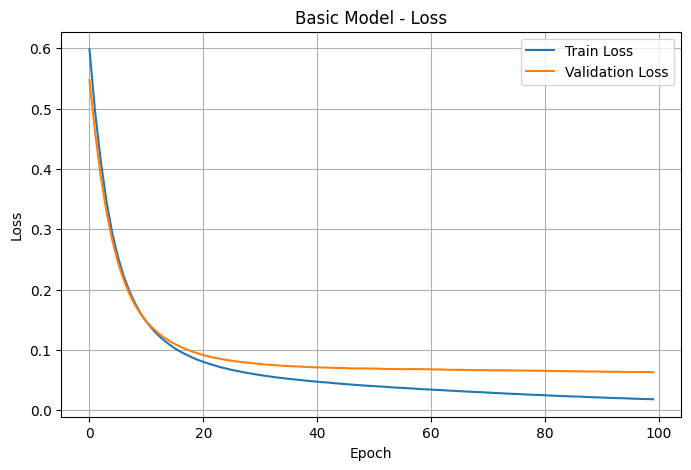

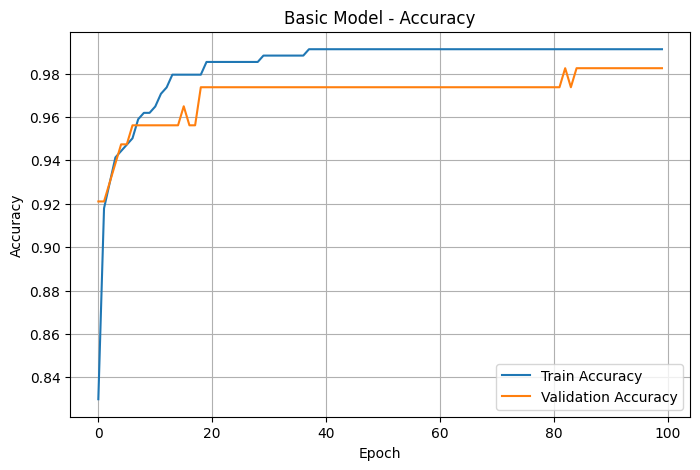

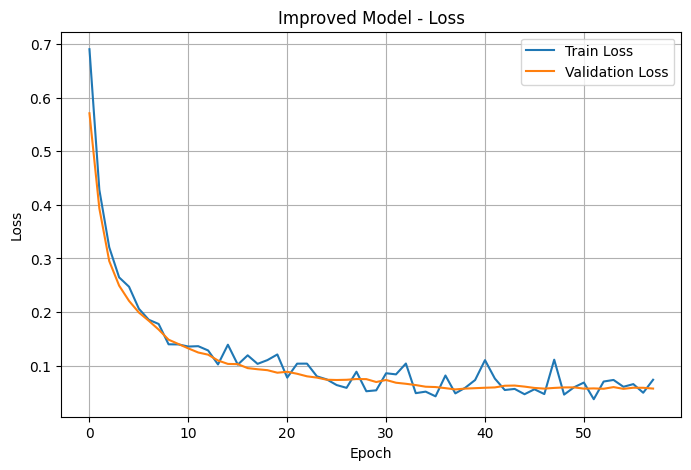

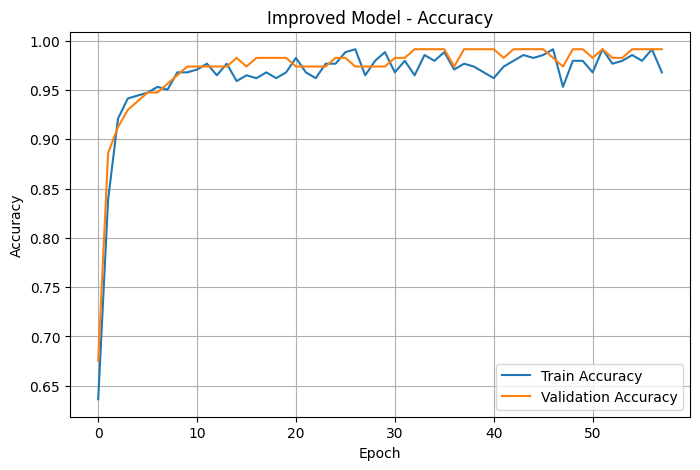

In [12]:
# ============================================================
# 12. 학습 곡선 시각화 함수
# ============================================================

def plot_history(history, title):
    # 손실 그래프를 그립니다.
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " - Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    # 정확도 그래프를 그립니다.
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_acc"], label="Train Accuracy")
    plt.plot(history["val_acc"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title + " - Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


# 기본 모델의 학습 과정 그래프를 출력합니다.
plot_history(basic_history, "Basic Model")

# 개선 모델의 학습 과정 그래프를 출력합니다.
plot_history(improved_history, "Improved Model")


In [13]:
# ============================================================
# 13. 테스트 데이터 최종 평가
# ============================================================

def predict_all(model, loader):
    # 모델을 평가 모드로 전환합니다.
    model.eval()

    # 전체 예측값과 전체 정답값을 저장할 리스트입니다.
    all_preds = []
    all_targets = []

    # 평가 시에는 기울기 계산을 하지 않습니다.
    with torch.no_grad():
        for batch_X, batch_y in loader:
            batch_X = batch_X.to(device)

            # 모델 예측 점수를 계산합니다.
            outputs = model(batch_X)

            # 가장 높은 점수를 가진 클래스를 최종 예측값으로 선택합니다.
            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            # 예측값과 실제 정답을 리스트에 저장합니다.
            all_preds.extend(preds)
            all_targets.extend(batch_y.numpy())

    return np.array(all_targets), np.array(all_preds)


# 기본 모델의 테스트 예측 결과를 구합니다.
y_true_basic, y_pred_basic = predict_all(basic_model, test_loader)

# 개선 모델의 테스트 예측 결과를 구합니다.
y_true_improved, y_pred_improved = predict_all(improved_model, test_loader)

# 정확도를 계산합니다.
basic_test_acc = accuracy_score(y_true_basic, y_pred_basic)
improved_test_acc = accuracy_score(y_true_improved, y_pred_improved)

print("기본 모델 테스트 정확도:", round(basic_test_acc, 4))
print("개선 모델 테스트 정확도:", round(improved_test_acc, 4))


기본 모델 테스트 정확도: 0.9561
개선 모델 테스트 정확도: 0.9474


In [ ]:
# ============================================================
# 14. 혼동행렬과 분류 리포트 확인
# ============================================================

# 혼동행렬은 모델이 어떤 클래스를 맞히고 틀렸는지 표로 보여줍니다.
print("기본 모델 혼동행렬")
print(confusion_matrix(y_true_basic, y_pred_basic))

print("\n개선 모델 혼동행렬")
print(confusion_matrix(y_true_improved, y_pred_improved))

# classification_report는 precision, recall, f1-score를 한 번에 보여줍니다.
print("\n기본 모델 분류 리포트")
print(classification_report(y_true_basic, y_pred_basic, target_names=data.target_names))

print("\n개선 모델 분류 리포트")
print(classification_report(y_true_improved, y_pred_improved, target_names=data.target_names))


In [ ]:
# ============================================================
# 15. 결과 비교표 만들기
# ============================================================

# 테스트 결과를 표 형태로 정리합니다.
result_df = pd.DataFrame({
    "Model": ["Basic MLP", "Improved MLP"],
    "Test Accuracy": [basic_test_acc, improved_test_acc],
    "Applied Methods": [
        "StandardScaler + Simple MLP + Adam",
        "StandardScaler + Deeper MLP + BatchNorm + Dropout + AdamW + Weight Decay + Scheduler + Early Stopping"
    ]
})

display(result_df)


# 정리

이 예제에서 성능 고도화 모델은 다음과 같은 방법을 적용했습니다.

## 기본 모델

- 단순한 MLP 구조
- Adam Optimizer
- StandardScaler 전처리

## 개선 모델

- 은닉층 수 증가
- Batch Normalization 적용
- Dropout 적용
- AdamW Optimizer 적용
- Weight Decay 적용
- Learning Rate Scheduler 적용
- Early Stopping 적용

실제 프로젝트에서는 성능이 항상 개선된다고 보장할 수는 없습니다.  
데이터 크기, 데이터 품질, 모델 구조, 하이퍼파라미터에 따라 결과가 달라질 수 있습니다.

중요한 점은 **기본 모델을 먼저 만들고, 하나씩 개선 방법을 적용하며 검증 데이터 기준으로 비교하는 것**입니다.
